# 一、核心概念
1. 定义与本质
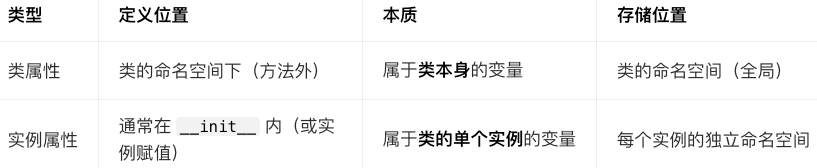
2. 基础示例：

In [4]:
class Student:
    # 类属性：定义在类内、方法外，所有实例共享
    school = "北京大学"  # 类命名空间
    count = 0           # 类属性：统计实例数量

    def __init__(self, name, score):
        # 实例属性：定义在__init__内，每个实例独有
        self.name = name  # 实例命名空间
        self.score = score  # 实例命名空间
        # 修改类属性（所有实例共享）
        Student.count += 1

# 1. 访问类属性（两种方式）
print(Student.school)  # 直接通过类访问（推荐）→ 北京大学
stu1 = Student("张三", 90)
print(stu1.school)     # 通过实例访问类属性 → 北京大学

# 2. 访问实例属性（只能通过实例）
print(stu1.name)       # → 张三
# print(Student.name)  # 报错！类无法直接访问实例属性（AttributeError）

# 3. 类属性的共享性
stu2 = Student("李四", 85)
print(stu1.count)      # → 2（stu1和stu2共享count）
stu1.count += 1
print(stu1.count)
print(stu2.count)      # → 2
print(Student.count)   # → 2

北京大学
北京大学
张三
2
3
2
2


3. 核心作用域规则
- 类属性：
    - 作用域：整个类的生命周期，所有该类的实例都能访问/共享；
    - 访问：类名.类属性（推荐）或 实例名.类属性；
    - 修改：必须通过 类名.类属性 修改（通过实例修改会「遮蔽」而非修改）。
- 实例属性：
    - 作用域：仅属于当前实例，不同实例的同名属性互不干扰；
    - 访问/修改：只能通过 实例名.示例属性，类名无法直接访问。

# 二、访问权限
Python 没有像 Java/C++ 那样严格的 public/private/protected 访问控制，但有约定俗成的私有属性规则，这一规则同时适用于类属性和实例属性：
1. 访问权限分类：
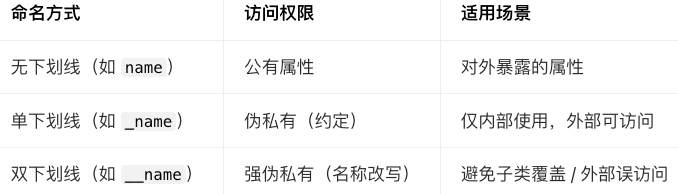
2. 示例：访问权限与类/示例属性

In [5]:
class Student:
    # 类属性的访问权限
    public_school = "北京大学"    # 公有类属性
    _private_school = "清华附中"  # 伪私有类属性
    __secret_school = "保密学校" # 强伪私有类属性

    def __init__(self, name):
        # 实例属性的访问权限
        self.public_name = name       # 公有实例属性
        self._private_age = 18        # 伪私有实例属性
        self.__secret_score = 90      # 强伪私有实例属性

# 1. 公有属性：自由访问
stu = Student("张三")
print(Student.public_school)  # → 北京大学
print(stu.public_name)        # → 张三

# 2. 单下划线伪私有：外部可访问（仅约定不建议）
print(Student._private_school) # → 清华附中
print(stu._private_age)        # → 18

# 3. 双下划线强伪私有：Python 会自动改写名称（名称重整）
# print(Student.__secret_school)  # 直接访问报错！
# print(stu.__secret_score)       # 直接访问报错！
# 改写规则：_类名__属性名
print(Student._Student__secret_school) # → 保密学校（强行访问）
print(stu._Student__secret_score)       # → 90（强行访问）

北京大学
张三
清华附中
18
保密学校
90


3. 关键说明
- 单下划线 _：仅作为「编程规范」，告诉开发者 “这个属性仅内部使用”，Python 不做任何限制。
- 双下划线 __：触发「名称改写（Name Mangling）」，目的是避免子类覆盖父类的私有属性，而非完全禁止访问（仍可通过 _类名__属性名 强行访问）。
- 访问权限规则同时适用于类属性和实例属性，核心是「命名约定」而非语言强制限制。

# 三、命名空间对比：类 / 实例属性 vs 函数内变量 vs 代码块内变量
Python 的命名空间是「层级化」的：
内置命名空间（如 print） → 全局命名空间（模块级变量） → 类命名空间（类属性） → 实例命名空间（实例属性） → 函数局部命名空间（函数内变量）
1. 函数内变量（局部/全局/nonlocal）：函数内的变量有自己的局部命名空间，与类 / 实例属性的命名空间完全隔离。

In [8]:
# 全局命名空间变量
global_school = "全国通用学校"

class Student:
    # 类命名空间属性
    class_school = "北京大学"

    def __init__(self):
        # 实例命名空间属性
        self.instance_school = "北京四中"

    def func(self):
        # 全局变量修改（需声明global）
        global global_school
        # 函数局部命名空间变量
        local_school = "班级专属教室"

        # 访问不同层级的变量/属性
        print(local_school)          # 局部变量 → 班级专属教室
        print(global_school)         # 全局变量 → 全国通用学校
        print(Student.class_school)  # 类属性 → 北京大学
        print(self.instance_school)  # 实例属性 → 北京四中

        global_school = "修改后的全局学校"

stu = Student()
stu.func()
print(global_school)  # → 修改后的全局学校

班级专属教室
全国通用学校
北京大学
北京四中
修改后的全局学校


2. 代码块内变量（for/if/while等）：Python 中普通代码块（if/for/while）不创建新的命名空间，变量会直接进入当前层级的命名空间（全局 / 函数局部），这和类 / 函数的命名空间不同。

In [9]:
# 示例1：全局代码块
if True:
    block_var = "代码块变量"
print(block_var)  # → 代码块变量（未创建新命名空间）

# 示例2：函数内代码块
def func():
    for i in range(2):
        loop_var = i
    print(loop_var)  # → 1（循环代码块不创建局部命名空间）

func()

# 对比：类/函数会创建独立命名空间
class MyClass:
    class_var = "类变量"
# print(class_var)  # 报错！类命名空间隔离

def my_func():
    func_var = "函数变量"
# print(func_var)  # 报错！函数局部命名空间隔离

代码块变量
1


3. 命名空间查找规则：当你访问一个名称（如 x）时，Python 会按以下顺序查找：
    1. 当前局部命名空间（函数内变量）→
    2. 实例命名空间（实例属性 self.x）→
    3. 类命名空间（类属性 Class.x）→
    4. 父类命名空间（继承）→
    5. 全局命名空间 →
    6. 内置命名空间。
- 找到即停止，未找到则抛出 AttributeError。

# 四、易错点
1. 实例“遮蔽”类属性（同名时）：当实例属性和类属性同名时，实例属性会「遮蔽」类属性（查找时优先返回实例属性）。

In [10]:
class Student:
    school = "北京大学"  # 类属性

stu1 = Student()
print(stu1.school)  # → 北京大学（访问类属性）

# 给实例新增同名属性（遮蔽类属性）
stu1.school = "清华大学"
print(stu1.school)  # → 清华大学（实例属性）
print(Student.school) # → 北京大学（类属性未变）

# 删除实例属性后，恢复访问类属性
del stu1.school
print(stu1.school)  # → 北京大学

北京大学
清华大学
北京大学
北京大学


2. 试图通过实例修改类属性（实际是新增实例属性）：这是最常见的错误！通过 实例.类属性 = 值 不会修改类属性，而是给实例新增一个同名属性。

In [11]:
class Student:
    count = 0  # 类属性

stu1 = Student()
stu1.count = 1  # 不是修改类属性，而是给stu1新增count实例属性

print(stu1.count)  # → 1（实例属性）
print(Student.count) # → 0（类属性未变）
print(stu2.count)  # → 0（其他实例仍访问类属性）

# 正确修改类属性的方式：通过类名
Student.count = 2
print(Student.count) # → 2
print(stu1.count)    # → 1（stu1有同名实例属性，仍遮蔽）

1
0
2
2
1


3. 混淆函数内变量和实例/类属性：函数内直接赋值的变量是「局部变量」，而非实例 / 类属性，需通过 self/类名 明确引用。

In [12]:
class Student:
    class_var = 10

    def __init__(self):
        self.instance_var = 20

    def wrong_func(self):
        class_var = 100  # 局部变量，不是修改类属性
        instance_var = 200 # 局部变量，不是修改实例属性
        print(class_var)    # → 100（局部）
        print(instance_var) # → 200（局部）

    def right_func(self):
        Student.class_var = 100  # 修改类属性
        self.instance_var = 200  # 修改实例属性
        print(Student.class_var) # → 100
        print(self.instance_var) # → 200

stu = Student()
stu.wrong_func()
print(Student.class_var) # → 10（类属性未变）
print(stu.instance_var)  # → 20（实例属性未变）

stu.right_func()
print(Student.class_var) # → 100
print(stu.instance_var)  # → 200

100
200
10
20
100
200
100
200


4. 误以为双下划线属性完全不可访问：双下划线属性只是「名称改写」，并非真正私有，不要依赖它做安全控制。

In [13]:
class Student:
    __secret = "保密信息"

stu = Student()
# print(stu.__secret)  # 直接访问报错
print(stu._Student__secret) # → 保密信息（仍可强行访问）

保密信息


## 综合示例

In [14]:
# 全局命名空间
global_config = {"version": "1.0"}

class Student:
    # 类属性（公有+伪私有）
    school = "北京大学"
    _total_students = 0

    def __init__(self, name, score):
        # 实例属性（公有+强伪私有）
        self.name = name
        self.__score = score  # 强伪私有，避免外部直接修改
        # 修改类属性
        Student._total_students += 1

    def get_score(self):
        # 函数内局部变量
        prefix = "分数："
        # 访问实例属性（强伪私有）+ 局部变量 + 类属性
        return f"{prefix}{self._Student__score}（{Student.school}）"

    def update_score(self, new_score):
        # 校验逻辑（函数内代码块）
        if 0 <= new_score <= 100:
            self.__score = new_score
        else:
            raise ValueError("分数必须在0-100之间")

# 访问全局变量
print(global_config["version"])  # → 1.0

# 创建实例
stu1 = Student("张三", 90)
stu2 = Student("李四", 85)

# 访问类属性
print(Student.school)          # → 北京大学
print(Student._total_students) # → 2（伪私有，内部使用）

# 访问实例方法（间接获取强伪私有属性）
print(stu1.get_score())        # → 分数：90（北京大学）

# 修改实例属性（通过方法，而非直接访问）
stu1.update_score(95)
print(stu1.get_score())        # → 分数：95（北京大学）

# 错误尝试：直接修改强伪私有属性
# stu1.__score = 150  # 实际是新增属性，而非修改
# print(stu1.get_score())  # → 分数：95（北京大学）

# 易错点：实例遮蔽类属性
stu1.school = "清华大学"
print(stu1.school)            # → 清华大学（实例属性）
print(Student.school)         # → 北京大学（类属性未变）

1.0
北京大学
2
分数：90（北京大学）
分数：95（北京大学）
清华大学
北京大学
